# Unemployment Analysis 

## Project Goal

In this notebook, we will analyze unemployment data for India.

The task is to:

- Analyze unemployment rate data.
- Clean and explore the dataset.
- Visualize unemployment trends.
- Investigate the effect of Covid-19 on unemployment.
- Identify important patterns.
- Present useful economic and social insights.

---

## How to use this notebook

Run this notebook **from top to bottom**.

Each section has:

1. **Markdown explanation** — what we are doing and why.
2. **Python code** — the actual analysis.
3. **Comments inside the code** — to help you understand each line.
4. **Interpretation** — what the result means.

This notebook uses two datasets:

- `Unemployment in India.csv`
- `Unemployment_Rate_upto_11_2020.csv`

# Step 0: Import Important Libraries

Before working with data, we import the libraries we need.

### Libraries used

- **pandas**: for reading, cleaning, and analyzing data.
- **numpy**: for numerical operations.
- **matplotlib**: for creating graphs.
- **pathlib**: for handling file paths safely.

We are using only common beginner-friendly libraries.

In [1]:
# Import the required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# This makes pandas show more columns when displaying dataframes
pd.set_option("display.max_columns", 50)

# This makes plots display clearly inside Jupyter Notebook
%matplotlib inline

Matplotlib is building the font cache; this may take a moment.


# Step 1: Load and Understand the Dataset

Before cleaning or plotting anything, we need to understand the dataset.

We will check:

- How many rows and columns are present?
- What are the column names?
- What type of data is in each column?
- What does the first few rows look like?

This step is important because we should never start analysis without understanding the data first.

In [2]:
# File names
# Keep these CSV files in the same folder as this notebook.
file_1 = Path("Unemployment in India.csv")
file_2 = Path("Unemployment_Rate_upto_11_2020.csv")

# Backup path for this ChatGPT environment
# This helps the notebook run here, but on your laptop the files should be in the same folder.
if not file_1.exists():
    file_1 = Path("/mnt/data/Unemployment in India.csv")

if not file_2.exists():
    file_2 = Path("/mnt/data/Unemployment_Rate_upto_11_2020.csv")

# Read both CSV files
raw_df = pd.read_csv(file_1)
raw_geo_df = pd.read_csv(file_2)

# Display shapes of both datasets
print("Shape of first dataset:", raw_df.shape)
print("Shape of second dataset:", raw_geo_df.shape)

Shape of first dataset: (768, 7)
Shape of second dataset: (267, 9)


In [3]:
# Display the first 5 rows of the first dataset
raw_df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


In [4]:
# Display the first 5 rows of the second dataset
raw_geo_df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Region.1,longitude,latitude
0,Andhra Pradesh,31-01-2020,M,5.48,16635535,41.02,South,15.9129,79.74
1,Andhra Pradesh,29-02-2020,M,5.83,16545652,40.90,South,15.9129,79.74
2,Andhra Pradesh,31-03-2020,M,5.79,15881197,39.18,South,15.9129,79.74
3,Andhra Pradesh,30-04-2020,M,20.51,11336911,33.10,South,15.9129,79.74
4,Andhra Pradesh,31-05-2020,M,17.43,12988845,36.46,South,15.9129,79.74


In [5]:
# Check column names and data types for the first dataset
raw_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    740 non-null    object 
 1    Date                                     740 non-null    object 
 2    Frequency                                740 non-null    object 
 3    Estimated Unemployment Rate (%)          740 non-null    float64
 4    Estimated Employed                       740 non-null    float64
 5    Estimated Labour Participation Rate (%)  740 non-null    float64
 6   Area                                      740 non-null    object 
dtypes: float64(3), object(4)
memory usage: 42.1+ KB


In [6]:
# Check column names and data types for the second dataset
raw_geo_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 267 entries, 0 to 266
Data columns (total 9 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    267 non-null    object 
 1    Date                                     267 non-null    object 
 2    Frequency                                267 non-null    object 
 3    Estimated Unemployment Rate (%)          267 non-null    float64
 4    Estimated Employed                       267 non-null    int64  
 5    Estimated Labour Participation Rate (%)  267 non-null    float64
 6   Region.1                                  267 non-null    object 
 7   longitude                                 267 non-null    float64
 8   latitude                                  267 non-null    float64
dtypes: float64(4), int64(1), object(4)
memory usage: 18.9+ KB


## Understanding the Columns

The important columns are:

| Column | Meaning |
|---|---|
| Region | State or region in India |
| Date | Month/date of the unemployment record |
| Frequency | Data frequency, usually monthly |
| Estimated Unemployment Rate (%) | Percentage of unemployed people |
| Estimated Employed | Estimated number of employed people |
| Estimated Labour Participation Rate (%) | Percentage of people participating in the labour market |
| Area | Rural or Urban |
| Region.1 | Broader Indian region group such as North, South, East, etc. |
| longitude / latitude | Coordinates useful for geographic visualization |

The first file has **Area** information: Rural and Urban.

The second file has **longitude, latitude, and regional group** information.

# Step 2: Data Cleaning

Data cleaning is one of the most important parts of data analysis.

In this step we will:

- Remove rows where every value is missing.
- Remove extra spaces from column names.
- Rename long column names into simpler names.
- Convert the Date column into proper datetime format.
- Remove extra spaces from text values.
- Check missing values.
- Check duplicate rows.

Clean data makes our graphs and conclusions more reliable.

In [7]:
# Check missing values in the raw first dataset
raw_df.isna().sum()

Region                                      28
 Date                                       28
 Frequency                                  28
 Estimated Unemployment Rate (%)            28
 Estimated Employed                         28
 Estimated Labour Participation Rate (%)    28
Area                                        28
dtype: int64

In [8]:
# Check rows where ALL columns are missing
# These rows do not contain useful information.
all_nan_rows = raw_df[raw_df.isna().all(axis=1)]

print("Number of rows where all columns are NaN:", len(all_nan_rows))
all_nan_rows.head()

Number of rows where all columns are NaN: 28


,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
359,NaN,NaN,NaN,NaN,NaN,NaN,NaN
360,NaN,NaN,NaN,NaN,NaN,NaN,NaN
361,NaN,NaN,NaN,NaN,NaN,NaN,NaN
362,NaN,NaN,NaN,NaN,NaN,NaN,NaN
363,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
def clean_unemployment_data(df):
    """
    This function cleans the unemployment dataset.

    It does the following:
    1. Drops rows where all values are missing.
    2. Cleans column names.
    3. Renames columns to shorter and easier names.
    4. Converts date into datetime format.
    5. Cleans text columns by removing extra spaces.
    6. Converts numeric columns into numbers.
    7. Removes duplicate rows.
    """

    # Make a copy so we do not change the original dataset
    df = df.copy()

    # 1. Remove rows where every column is missing
    df = df.dropna(how="all")

    # 2. Clean column names
    # Example: " Estimated Unemployment Rate (%)" becomes "estimated_unemployment_rate_percent"
    df.columns = (
        df.columns
        .str.strip()
        .str.lower()
        .str.replace(" ", "_", regex=False)
        .str.replace(".", "_", regex=False)
        .str.replace("(", "", regex=False)
        .str.replace(")", "", regex=False)
        .str.replace("%", "percent", regex=False)
    )

    # 3. Rename important columns to simpler names
    df = df.rename(columns={
        "estimated_unemployment_rate_percent": "unemployment_rate",
        "estimated_employed": "estimated_employed",
        "estimated_labour_participation_rate_percent": "labour_participation_rate",
        "region_1": "region_group"
    })

    # 4. Convert date column into proper datetime format
    # dayfirst=True is important because the dates look like 31-05-2019
    if "date" in df.columns:
        df["date"] = pd.to_datetime(df["date"].astype(str).str.strip(), dayfirst=True, errors="coerce")

    # 5. Remove extra spaces from text columns
    text_columns = df.select_dtypes(include="object").columns
    for col in text_columns:
        df[col] = df[col].astype(str).str.strip()

    # 6. Convert numeric columns to numeric type
    numeric_columns = ["unemployment_rate", "estimated_employed", "labour_participation_rate", "longitude", "latitude"]
    for col in numeric_columns:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")

    # 7. Remove duplicate rows
    df = df.drop_duplicates()

    return df

In [10]:
# Clean both datasets using our function
df = clean_unemployment_data(raw_df)
geo_df = clean_unemployment_data(raw_geo_df)

print("Cleaned first dataset shape:", df.shape)
print("Cleaned second dataset shape:", geo_df.shape)

Cleaned first dataset shape: (740, 7)
Cleaned second dataset shape: (267, 9)


In [11]:
# Check cleaned column names
df.columns

Index(['region', 'date', 'frequency', 'unemployment_rate',
       'estimated_employed', 'labour_participation_rate', 'area'],
      dtype='object')

In [12]:
# Check missing values after cleaning
df.isna().sum()

region                       0
date                         0
frequency                    0
unemployment_rate            0
estimated_employed           0
labour_participation_rate    0
area                         0
dtype: int64

In [13]:
# Check duplicate rows after cleaning
print("Duplicate rows in first dataset:", df.duplicated().sum())
print("Duplicate rows in second dataset:", geo_df.duplicated().sum())

Duplicate rows in first dataset: 0
Duplicate rows in second dataset: 0


In [14]:
# Display cleaned dataset
df.head()

,region,date,frequency,unemployment_rate,estimated_employed,labour_participation_rate,area
0,Andhra Pradesh,2019-05-31,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,2019-06-30,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,2019-07-31,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,2019-08-31,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,2019-09-30,Monthly,5.17,12256762.0,44.68,Rural


## Cleaning Interpretation

After cleaning:

- Rows where all values were missing have been removed.
- Column names are now easier to use.
- The Date column has been converted into a real date format.
- Duplicate rows have been checked.
- The dataset is now ready for analysis.

This is important because messy column names and missing values can create errors during plotting and grouping.

# Step 3: Explore the Data

Now we start exploring the data.

In this step, we will answer questions like:

- What is the average unemployment rate?
- Which regions have high unemployment?
- Which regions have low unemployment?
- Is unemployment different in rural and urban areas?
- What is the month-by-month unemployment trend?

This is called **Exploratory Data Analysis**, or EDA.

In [15]:
# Basic summary statistics for numerical columns
df[["unemployment_rate", "estimated_employed", "labour_participation_rate"]].describe()

,unemployment_rate,estimated_employed,labour_participation_rate
count,740.000000,7.400000e+02,740.000000
mean,11.787946,7.204460e+06,42.630122
std,10.721298,8.087988e+06,8.111094
min,0.000000,4.942000e+04,13.330000
25%,4.657500,1.190404e+06,38.062500
50%,8.350000,4.744178e+06,41.160000
75%,15.887500,1.127549e+07,45.505000
max,76.740000,4.577751e+07,72.570000


In [16]:
# Number of unique regions and areas
print("Number of regions:", df["region"].nunique())
print("Areas in dataset:", df["area"].unique())
print("Date range:", df["date"].min(), "to", df["date"].max())

Number of regions: 28
Areas in dataset: ['Rural' 'Urban']
Date range: 2019-05-31 00:00:00 to 2020-06-30 00:00:00


In [17]:
# Average unemployment rate by region
region_unemployment = (
    df.groupby("region")["unemployment_rate"]
    .mean()
    .sort_values(ascending=False)
)

region_unemployment.head(10)

region
Tripura             28.350357
Haryana             26.283214
Jharkhand           20.585000
Bihar               18.918214
Himachal Pradesh    18.540357
Delhi               16.495357
Jammu & Kashmir     16.188571
Chandigarh          15.991667
Rajasthan           14.058214
Uttar Pradesh       12.551429
Name: unemployment_rate, dtype: float64

In [18]:
# Regions with the lowest average unemployment rate
region_unemployment.tail(10)

region
Maharashtra       7.557500
Andhra Pradesh    7.477143
Madhya Pradesh    7.406429
Sikkim            7.249412
Karnataka         6.676071
Gujarat           6.663929
Uttarakhand       6.582963
Assam             6.428077
Odisha            5.657857
Meghalaya         4.798889
Name: unemployment_rate, dtype: float64

In [19]:
# Average unemployment rate by area: Rural vs Urban
area_unemployment = (
    df.groupby("area")["unemployment_rate"]
    .mean()
    .sort_values(ascending=False)
)

area_unemployment

area
Urban    13.166614
Rural    10.324791
Name: unemployment_rate, dtype: float64

In [20]:
# Month-wise average unemployment rate
monthly_unemployment = (
    df.groupby(df["date"].dt.to_period("M"))["unemployment_rate"]
    .mean()
    .reset_index()
)

# Convert period back to timestamp for easier plotting
monthly_unemployment["date"] = monthly_unemployment["date"].dt.to_timestamp()

monthly_unemployment

,date,unemployment_rate
0,2019-05-01,8.874259
1,2019-06-01,9.303333
2,2019-07-01,9.033889
3,2019-08-01,9.637925
4,2019-09-01,9.051731
5,2019-10-01,9.900909
6,2019-11-01,9.868364
7,2019-12-01,9.497358
8,2020-01-01,9.950755
9,2020-02-01,9.964717


## Exploration Interpretation

At this point, we are not yet making final conclusions.

We are simply learning what the data says.

Things to notice:

- Some regions have much higher average unemployment than others.
- Urban and rural unemployment can be different.
- The month-wise table helps us see whether unemployment increased during 2020.

The next step is visualization, because graphs make trends easier to understand.

# Step 4: Data Visualization

Visualization helps us understand patterns quickly.

We will create:

1. Line chart of unemployment over time.
2. Bar chart of unemployment by region.
3. Rural vs Urban comparison.
4. Employment trend over time.
5. Labour participation trend over time.
6. Simple geographic scatter plot using latitude and longitude.

For every graph, always ask:

- What is on the x-axis?
- What is on the y-axis?
- What pattern do I see?
- What insight can I explain from this graph?

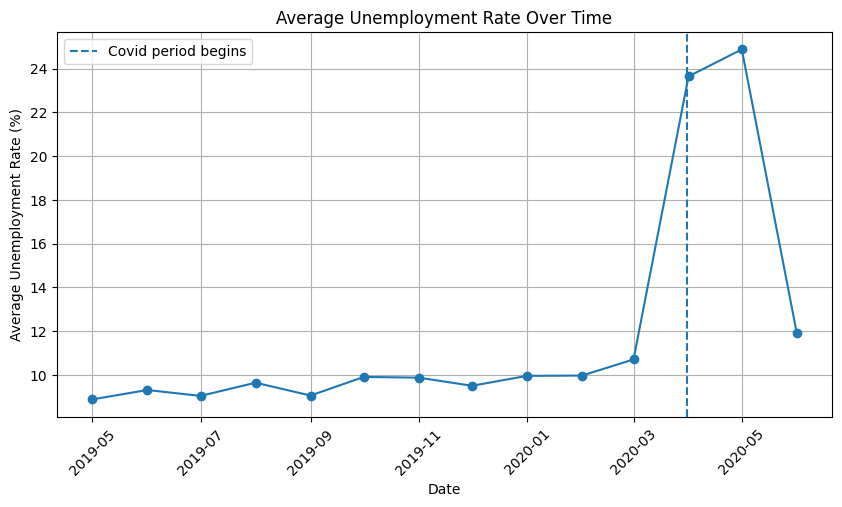

In [21]:
# 1. Overall unemployment trend over time

plt.figure(figsize=(10, 5))

plt.plot(monthly_unemployment["date"], monthly_unemployment["unemployment_rate"], marker="o")

# Covid lockdown started becoming visible in India around March/April 2020
plt.axvline(pd.Timestamp("2020-03-31"), linestyle="--", label="Covid period begins")

plt.title("Average Unemployment Rate Over Time")
plt.xlabel("Date")
plt.ylabel("Average Unemployment Rate (%)")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.show()

### Interpretation

This graph shows the overall unemployment trend over time.

A clear spike around **April and May 2020** suggests that unemployment increased sharply during the early Covid-19 lockdown period.

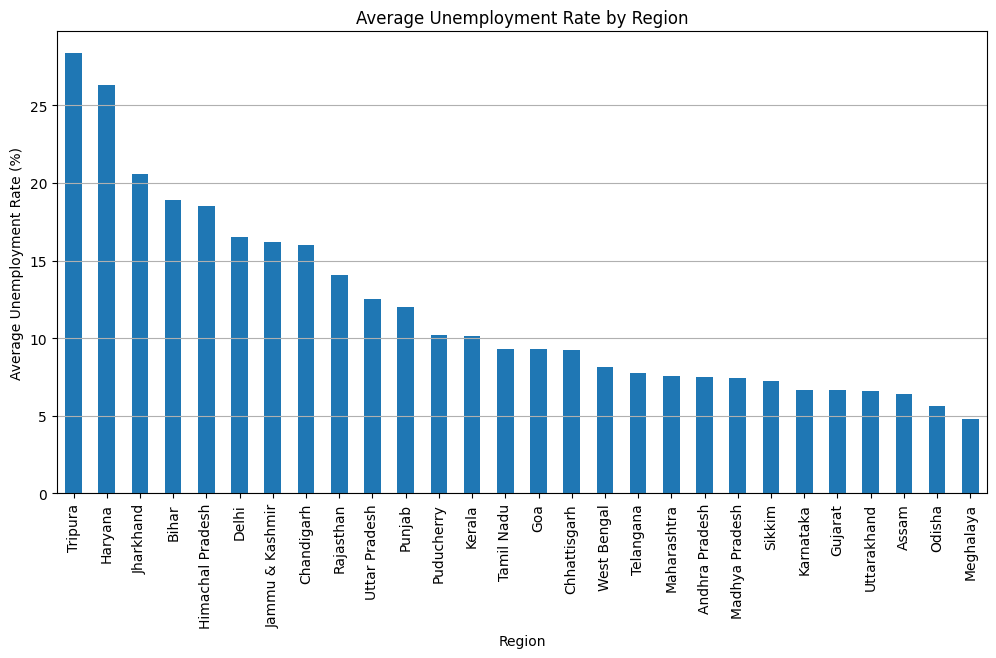

In [22]:
# 2. Average unemployment rate by region

plt.figure(figsize=(12, 6))

region_unemployment.plot(kind="bar")

plt.title("Average Unemployment Rate by Region")
plt.xlabel("Region")
plt.ylabel("Average Unemployment Rate (%)")
plt.xticks(rotation=90)
plt.grid(axis="y")
plt.show()

### Interpretation

This graph helps identify which regions had the highest and lowest average unemployment rates.

Regions at the left side of the chart have higher average unemployment.

This is useful for regional economic analysis.

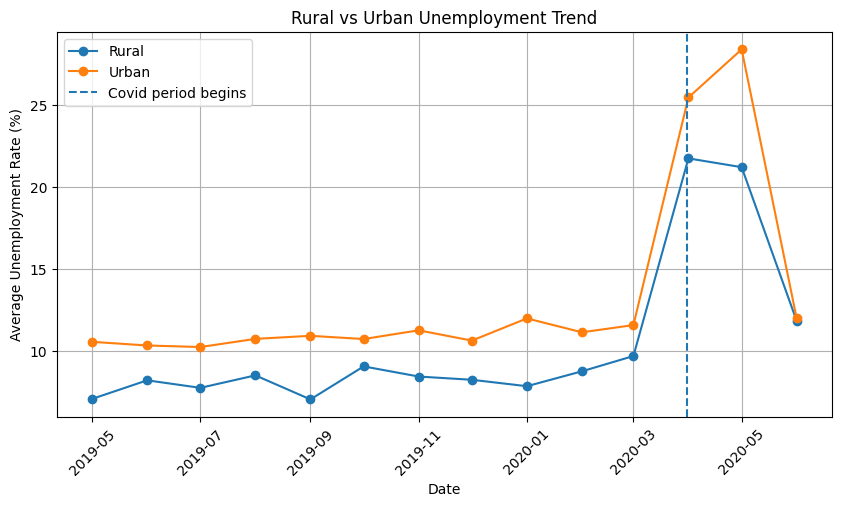

In [23]:
# 3. Rural vs Urban unemployment trend over time

area_monthly = (
    df.groupby([df["date"].dt.to_period("M"), "area"])["unemployment_rate"]
    .mean()
    .reset_index()
)

area_monthly["date"] = area_monthly["date"].dt.to_timestamp()

plt.figure(figsize=(10, 5))

for area in area_monthly["area"].unique():
    subset = area_monthly[area_monthly["area"] == area]
    plt.plot(subset["date"], subset["unemployment_rate"], marker="o", label=area)

plt.axvline(pd.Timestamp("2020-03-31"), linestyle="--", label="Covid period begins")

plt.title("Rural vs Urban Unemployment Trend")
plt.xlabel("Date")
plt.ylabel("Average Unemployment Rate (%)")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.show()

### Interpretation

This graph compares rural and urban unemployment.

It helps us understand whether Covid affected rural and urban areas in the same way or differently.

In many cases, urban employment can be more sensitive to lockdowns because cities depend heavily on services, transport, shops, construction, and other movement-based jobs.

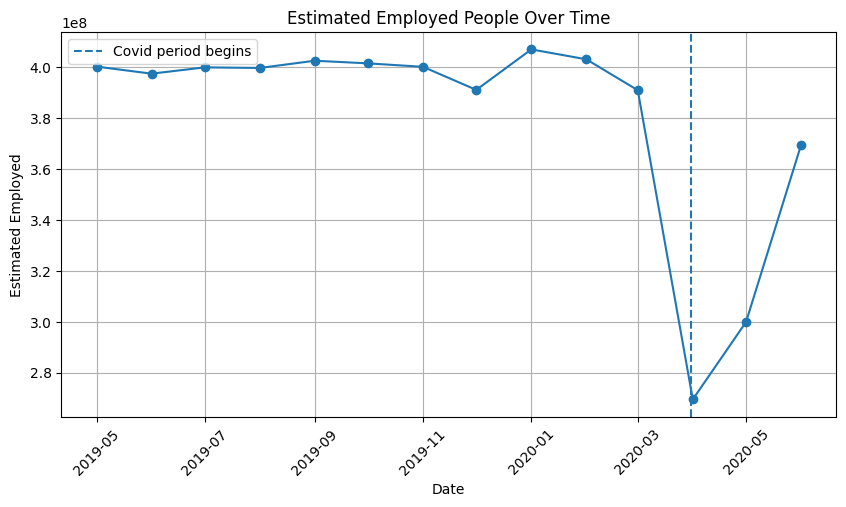

In [24]:
# 4. Estimated employed people over time

monthly_employed = (
    df.groupby(df["date"].dt.to_period("M"))["estimated_employed"]
    .sum()
    .reset_index()
)

monthly_employed["date"] = monthly_employed["date"].dt.to_timestamp()

plt.figure(figsize=(10, 5))

plt.plot(monthly_employed["date"], monthly_employed["estimated_employed"], marker="o")

plt.axvline(pd.Timestamp("2020-03-31"), linestyle="--", label="Covid period begins")

plt.title("Estimated Employed People Over Time")
plt.xlabel("Date")
plt.ylabel("Estimated Employed")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.show()

### Interpretation

This graph shows the estimated number of employed people over time.

If the unemployment rate rises and estimated employment falls during the same period, that gives stronger evidence of job loss or employment disruption.

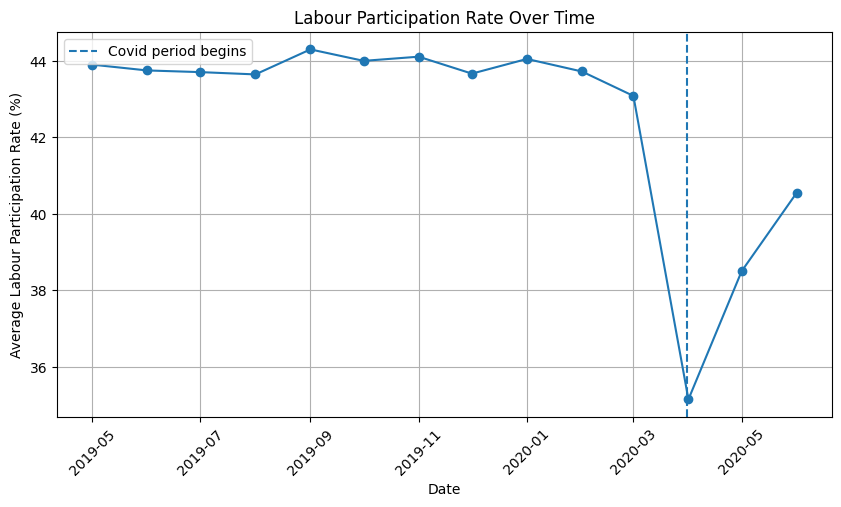

In [25]:
# 5. Labour participation rate over time

monthly_lpr = (
    df.groupby(df["date"].dt.to_period("M"))["labour_participation_rate"]
    .mean()
    .reset_index()
)

monthly_lpr["date"] = monthly_lpr["date"].dt.to_timestamp()

plt.figure(figsize=(10, 5))

plt.plot(monthly_lpr["date"], monthly_lpr["labour_participation_rate"], marker="o")

plt.axvline(pd.Timestamp("2020-03-31"), linestyle="--", label="Covid period begins")

plt.title("Labour Participation Rate Over Time")
plt.xlabel("Date")
plt.ylabel("Average Labour Participation Rate (%)")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.show()

### Interpretation

Labour participation rate tells us how many people are active in the labour market.

During an economic shock, some people may stop looking for work.  
So unemployment rate and labour participation rate should be studied together.

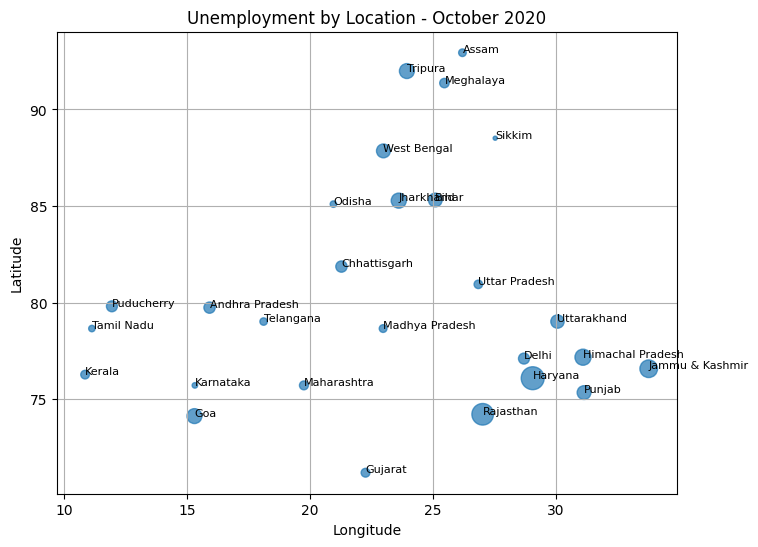

In [26]:
# 6. Simple geographic scatter plot using the second dataset

# We will use the latest month available in the geo dataset
latest_date = geo_df["date"].max()
latest_geo = geo_df[geo_df["date"] == latest_date]

plt.figure(figsize=(8, 6))

scatter = plt.scatter(
    latest_geo["longitude"],
    latest_geo["latitude"],
    s=latest_geo["unemployment_rate"] * 10,
    alpha=0.7
)

# Add region labels
for _, row in latest_geo.iterrows():
    plt.text(row["longitude"], row["latitude"], row["region"], fontsize=8)

plt.title(f"Unemployment by Location - {latest_date.strftime('%B %Y')}")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.grid(True)
plt.show()

### Interpretation

This is a simple geographic-style scatter plot.

Each point represents a region.  
The larger the point, the higher the unemployment rate.

This is not a full map, but it helps us visually compare unemployment across locations.

# Step 5: Covid-19 Impact Analysis

This is the most important part of the project.

We will compare unemployment before and during the Covid shock.

For this dataset:

- **Before Covid**: dates before March 2020.
- **Early Covid / Lockdown shock**: April 2020 and May 2020.
- **After early shock**: June 2020 onward, depending on the dataset.

The goal is to check whether unemployment increased sharply during the Covid period.

In [27]:
# Create a new column called covid_period
# This helps compare different time periods easily.

def covid_period(date):
    if date < pd.Timestamp("2020-03-01"):
        return "Before Covid"
    elif pd.Timestamp("2020-04-01") <= date <= pd.Timestamp("2020-05-31"):
        return "Early Covid Lockdown Shock"
    elif date >= pd.Timestamp("2020-06-01"):
        return "After Early Shock"
    else:
        return "Transition Month"

df["covid_period"] = df["date"].apply(covid_period)

df[["date", "region", "area", "unemployment_rate", "covid_period"]].head()

,date,region,area,unemployment_rate,covid_period
0,2019-05-31,Andhra Pradesh,Rural,3.65,Before Covid
1,2019-06-30,Andhra Pradesh,Rural,3.05,Before Covid
2,2019-07-31,Andhra Pradesh,Rural,3.75,Before Covid
3,2019-08-31,Andhra Pradesh,Rural,3.32,Before Covid
4,2019-09-30,Andhra Pradesh,Rural,5.17,Before Covid


In [28]:
# Average unemployment rate by Covid period

covid_comparison = (
    df.groupby("covid_period")["unemployment_rate"]
    .mean()
    .reindex(["Before Covid", "Transition Month", "Early Covid Lockdown Shock", "After Early Shock"])
)

covid_comparison

covid_period
Before Covid                   9.509534
Transition Month              10.700577
Early Covid Lockdown Shock    24.258431
After Early Shock             11.903600
Name: unemployment_rate, dtype: float64

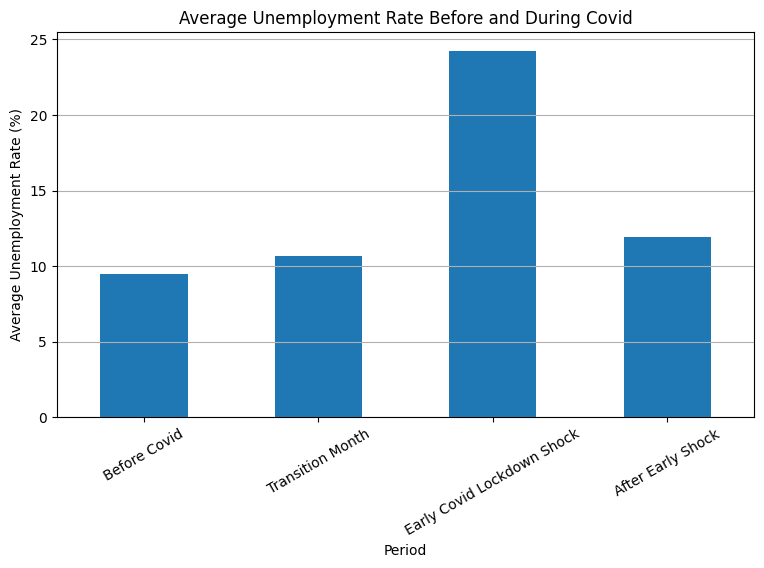

In [29]:
# Bar chart for Covid period comparison

plt.figure(figsize=(9, 5))

covid_comparison.plot(kind="bar")

plt.title("Average Unemployment Rate Before and During Covid")
plt.xlabel("Period")
plt.ylabel("Average Unemployment Rate (%)")
plt.xticks(rotation=30)
plt.grid(axis="y")
plt.show()

In [30]:
# Compare unemployment and labour participation together by Covid period

covid_multi_comparison = (
    df.groupby("covid_period")[["unemployment_rate", "labour_participation_rate"]]
    .mean()
    .reindex(["Before Covid", "Transition Month", "Early Covid Lockdown Shock", "After Early Shock"])
)

covid_multi_comparison

,unemployment_rate,labour_participation_rate
covid_period,,
Before Covid,9.509534,43.886119
Transition Month,10.700577,43.084038
Early Covid Lockdown Shock,24.258431,36.819020
After Early Shock,11.903600,40.548400


In [31]:
# Which regions were most affected during April-May 2020?

lockdown_df = df[df["covid_period"] == "Early Covid Lockdown Shock"]

lockdown_region_unemployment = (
    lockdown_df.groupby("region")["unemployment_rate"]
    .mean()
    .sort_values(ascending=False)
)

lockdown_region_unemployment.head(10)

region
Puducherry        75.416667
Jharkhand         57.117500
Bihar             47.247500
Tamil Nadu        40.855000
Haryana           40.295000
Tripura           27.502500
Delhi             26.435000
Karnataka         24.472500
Uttar Pradesh     23.952500
Andhra Pradesh    21.990000
Name: unemployment_rate, dtype: float64

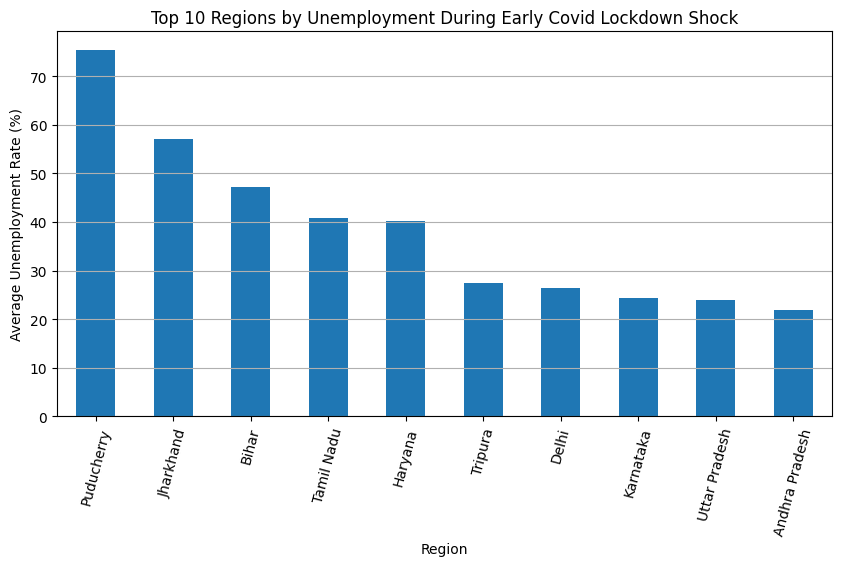

In [32]:
# Plot top 10 regions by unemployment during early Covid lockdown shock

plt.figure(figsize=(10, 5))

lockdown_region_unemployment.head(10).plot(kind="bar")

plt.title("Top 10 Regions by Unemployment During Early Covid Lockdown Shock")
plt.xlabel("Region")
plt.ylabel("Average Unemployment Rate (%)")
plt.xticks(rotation=75)
plt.grid(axis="y")
plt.show()

## Covid Impact Interpretation

The data shows a strong increase in unemployment around **April and May 2020**.

This suggests that the Covid-19 lockdown period had a major impact on employment.

A strong analysis should mention:

- Unemployment increased sharply during early Covid.
- Estimated employment dropped during the same period.
- Labour participation also changed, meaning people’s connection to the labour market was affected.
- Some regions were affected more than others.

# Step 6: Identify Patterns and Trends

Now we look for patterns.

Important note:

This dataset does not contain many years of data, so we should be careful when using the word **seasonal**.

A true seasonal pattern usually requires multiple years of data.

Here, we can say:

- We can identify monthly trends.
- We can identify Covid-related spikes.
- We can compare rural and urban patterns.
- We can compare regional patterns.

We should not make very strong claims like "every year unemployment rises in April" because the dataset does not have enough years.

In [33]:
# Add month name for monthly pattern analysis
df["month"] = df["date"].dt.month_name()

# Average unemployment by month name
month_pattern = (
    df.groupby("month")["unemployment_rate"]
    .mean()
    .sort_values(ascending=False)
)

month_pattern

month
April        23.641569
May          16.646190
March        10.700577
June         10.553462
February      9.964717
January       9.950755
October       9.900909
November      9.868364
August        9.637925
December      9.497358
September     9.051731
July          9.033889
Name: unemployment_rate, dtype: float64

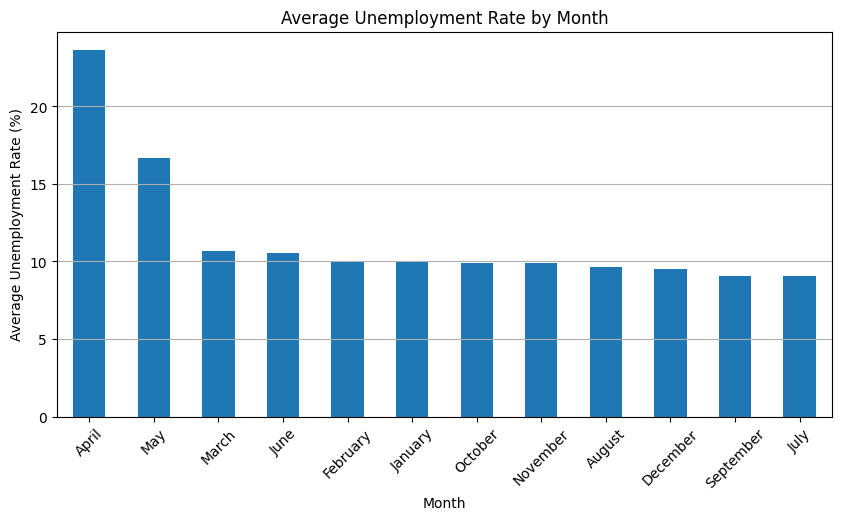

In [34]:
# Plot average unemployment by month

plt.figure(figsize=(10, 5))

month_pattern.plot(kind="bar")

plt.title("Average Unemployment Rate by Month")
plt.xlabel("Month")
plt.ylabel("Average Unemployment Rate (%)")
plt.xticks(rotation=45)
plt.grid(axis="y")
plt.show()

In [35]:
# Region and area pattern
# This table shows average unemployment by region and area.

region_area_pattern = (
    df.pivot_table(
        index="region",
        columns="area",
        values="unemployment_rate",
        aggfunc="mean"
    )
)

region_area_pattern.head(15)

area,Rural,Urban
region,,
Andhra Pradesh,5.526429,9.427857
Assam,4.490833,8.088571
Bihar,16.770000,21.066429
Chandigarh,NaN,15.991667
Chhattisgarh,6.628571,11.852143
Delhi,15.258571,17.732143
Goa,8.390000,10.158333
Gujarat,5.917143,7.410714
Haryana,25.012857,27.553571


In [36]:
# Difference between Urban and Rural unemployment for each region
# Positive value means Urban unemployment is higher than Rural unemployment.

region_area_pattern["urban_minus_rural"] = region_area_pattern.get("Urban") - region_area_pattern.get("Rural")

region_area_pattern.sort_values("urban_minus_rural", ascending=False).head(10)

area,Rural,Urban,urban_minus_rural
region,,,
Jharkhand,15.221429,25.948571,10.727143
Rajasthan,10.927143,17.189286,6.262143
Himachal Pradesh,15.504286,21.576429,6.072143
Puducherry,7.263333,12.745000,5.481667
Chhattisgarh,6.628571,11.852143,5.223571
Meghalaya,2.475000,7.301538,4.826538
Uttar Pradesh,10.208571,14.894286,4.685714
Bihar,16.770000,21.066429,4.296429
Andhra Pradesh,5.526429,9.427857,3.901429


## Pattern Interpretation

From these patterns, we can discuss:

- Which months show the highest unemployment.
- Whether urban unemployment is generally higher than rural unemployment.
- Which regions have the largest rural-urban difference.
- Whether the largest spike is related to Covid rather than normal seasonality.

Because the data covers a short time period, the strongest pattern is the **Covid-related unemployment spike**.

# Step 7: Final Insights and Conclusion

Now we summarize what we learned.

A good conclusion should not only describe graphs.  
It should explain the meaning of the analysis.

Below, we generate key numbers from the dataset and then write final insights.

In [37]:
# Important summary numbers

before_covid_avg = df[df["covid_period"] == "Before Covid"]["unemployment_rate"].mean()
lockdown_avg = df[df["covid_period"] == "Early Covid Lockdown Shock"]["unemployment_rate"].mean()
after_shock_avg = df[df["covid_period"] == "After Early Shock"]["unemployment_rate"].mean()

peak_month = monthly_unemployment.loc[monthly_unemployment["unemployment_rate"].idxmax()]

highest_region = region_unemployment.idxmax()
highest_region_value = region_unemployment.max()

lowest_region = region_unemployment.idxmin()
lowest_region_value = region_unemployment.min()

urban_avg = area_unemployment.get("Urban")
rural_avg = area_unemployment.get("Rural")

print("Average unemployment before Covid:", round(before_covid_avg, 2), "%")
print("Average unemployment during early Covid lockdown shock:", round(lockdown_avg, 2), "%")
print("Average unemployment after early shock:", round(after_shock_avg, 2), "%")
print()
print("Peak unemployment month:", peak_month["date"].strftime("%B %Y"))
print("Peak unemployment rate:", round(peak_month["unemployment_rate"], 2), "%")
print()
print("Region with highest average unemployment:", highest_region, "-", round(highest_region_value, 2), "%")
print("Region with lowest average unemployment:", lowest_region, "-", round(lowest_region_value, 2), "%")
print()
print("Average urban unemployment:", round(urban_avg, 2), "%")
print("Average rural unemployment:", round(rural_avg, 2), "%")

Average unemployment before Covid: 9.51 %
Average unemployment during early Covid lockdown shock: 24.26 %
Average unemployment after early shock: 11.9 %

Peak unemployment month: May 2020
Peak unemployment rate: 24.88 %

Region with highest average unemployment: Tripura - 28.35 %
Region with lowest average unemployment: Meghalaya - 4.8 %

Average urban unemployment: 13.17 %
Average rural unemployment: 10.32 %


## Final Insights

Based on the analysis:

1. **Unemployment increased sharply during early Covid-19.**  
   The average unemployment rate before Covid was much lower than during April-May 2020.

2. **The highest unemployment spike happened around April-May 2020.**  
   This matches the period when lockdown restrictions affected businesses, movement, and employment.

3. **Estimated employed people dropped strongly during the Covid shock.**  
   This supports the unemployment rate result and shows that the labour market was seriously affected.

4. **Urban and rural unemployment behaved differently.**  
   Urban unemployment was generally higher in this dataset, especially during the Covid shock.

5. **Some regions were more affected than others.**  
   This means unemployment was not equally distributed across India.

6. **Labour participation rate also changed.**  
   This is important because unemployment rate alone does not show the full labour market picture.

7. **Seasonality cannot be strongly confirmed from this dataset.**  
   The dataset covers a limited time range, so we can identify monthly trends, but we should be careful about claiming long-term seasonal patterns.

---

## Economic and Social Policy Insights

The analysis suggests that during major shocks like Covid-19:

- Job support programs may be needed quickly.
- Urban workers may need special support because city jobs are often affected by lockdowns.
- Region-specific policies are important because some regions are hit harder than others.
- Labour participation should be monitored along with unemployment rate.
- Recovery policies should focus not only on creating jobs but also on bringing people back into the labour force.



